## Installing and importing dependencies for the project

In [ ]:
#dont run!!!
%pip uninstall mediapipe -y

Found existing installation: mediapipe 0.10.14
Uninstalling mediapipe-0.10.14:
  Successfully uninstalled mediapipe-0.10.14
Note: you may need to restart the kernel to use updated packages.


In [1]:
import sys
print(sys.version) #need python 3.11.9
print(sys.maxsize > 2**32) #Python architecture:64-bit (True) or 32-bit (False)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
True


In [2]:
%pip install opencv-python scikit-learn mediapipe==0.10.14 matplotlib tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Importing them
import time 
import os
import cv2
import numpy as np
from matplotlib import pyplot as plt
import mediapipe as mp


## Keypoints (MP Holistic) 
1. Check and confirm web came availability using opencv.
2. Detections will then be made using mediapipe.

In [84]:
#Mediapipe holistic model
mp_holistic = mp.solutions.holistic
holistic = mp_holistic.Holistic()

#Mediapipe drawing utils
mp_drawing = mp.solutions.drawing_utils

In [42]:
# function: to make detections (convert from bgr to rgb then make img not writeable. make prediction then make the image writeable before converting rgb to bgr)
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 
    image.flags.writeable = False                  
    results = model.process(image)                 
    image.flags.writeable = True                   
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) 
    return image, results

### MediaPipe Landmark Connection Reference

* **`mp_holistic.POSE_CONNECTIONS` (Indices 0–32)**
  * **Face:** 0 (Nose), 1-3 (L Eye), 4-6 (R Eye), 7-8 (Ears), 9-10 (Mouth)
  * **Upper Body:** 11-12 (Shoulders), 13-14 (Elbows), 15-16 (Wrists)
  * **Hands:** 17, 19, 21 (L Hand digits) | 18, 20, 22 (R Hand digits)
  * **Lower Body:** 23-24 (Hips), 25-26 (Knees), 27-28 (Ankles), 29-32 (Heels/Toes)

* **`mp_holistic.HAND_CONNECTIONS` (Indices 0–20)**
  * **Base:** 0 (Wrist)
  * **Digits (Base to Tip):** 1-4 (Thumb), 5-8 (Index), 9-12 (Middle), 13-16 (Ring), 17-20 (Pinky)

* **`mp_holistic.FACEMESH_CONTOURS` (Indices 0–467)**
  * Tracks 468 dense facial points grouped into loops:
  * **Lips:** Outer (61–375) | Inner (78–402)
  * **Eyes & Brows:** Left (33–163 eye, 70–105 brow) | Right (263–398 eye, 300–334 brow)
  * **Face Oval:** Outer jaw and hairline silhouette (10 to 152 loop)

In [ ]:
# function: to draw the landmarks
def landmarks_draw(image, results):
    # 1. Draw Face Landmarks (FACEMESH_CONTOURS:outlines eyes lips and face shape  [or] FACEMESH_TESSELATION: forms a mesh over the entire face)
    if results.face_landmarks:
        mp_drawing.draw_landmarks(
            image, 
            results.face_landmarks, 
            mp_holistic.FACEMESH_CONTOURS,
            mp_drawing.DrawingSpec(color= (255,0,0), thickness=2, circle_radius=2), #bgr format, landmark
            mp_drawing.DrawingSpec(color= (255,0,255), thickness=2, circle_radius=2) #connecting parts
        )
        
    # 2. Draw Pose Landmarks
    if results.pose_landmarks:
        mp_drawing.draw_landmarks(
            image, 
            results.pose_landmarks, 
            mp_holistic.POSE_CONNECTIONS,
            mp_drawing.DrawingSpec(color= (0,255,255), thickness=1, circle_radius=1),
            mp_drawing.DrawingSpec(color= (0,0,255), thickness=1, circle_radius=1)
        )
        
    # 3. Draw Right Hand Landmarks (Using mp_holistic.HAND_CONNECTIONS)
    if results.right_hand_landmarks:
        mp_drawing.draw_landmarks(
            image, 
            results.right_hand_landmarks, 
            mp_holistic.HAND_CONNECTIONS
        )

    # 4. Draw Left Hand Landmarks (Using mp_holistic.HAND_CONNECTIONS)
    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(
            image, 
            results.left_hand_landmarks, 
            mp_holistic.HAND_CONNECTIONS
        )

In [92]:
#Access webcam (device 0). cap reads the feed from webcam and stores it.
cap = cv2.VideoCapture(0)

#access holistic model (detect then track)
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():
    #read feed (ret = return value (boolean), frame = image array)
        ret, frame = cap.read()

        #make detections
        image,results = mediapipe_detection(frame, holistic)
        print(results)

        #draw landmarks
        landmarks_draw(image, results)

        #show
        if ret!= True:
            print("Error reading frame from webcam. Exiting...")
            break
        else:
            cv2.imshow("Sign_Language_Detection", image)

        #if the key 'q' is pressed inside of the frame, exit the loop
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release() 
    cv2.destroyAllWindows() 

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

### Testing by frame (for testing in case the above code block has some issues. if fine, don't need to run the 8 code blocks after this)

In [58]:
#face landmarks
results.face_landmarks
len(results.face_landmarks.landmark)


468

In [67]:
#right_hand landmarks
results.right_hand_landmarks
len(results.right_hand_landmarks.landmark)

21

In [66]:
#left_hand landmarks
results.right_hand_landmarks
len(results.left_hand_landmarks.landmark)

AttributeError: 'NoneType' object has no attribute 'landmark'

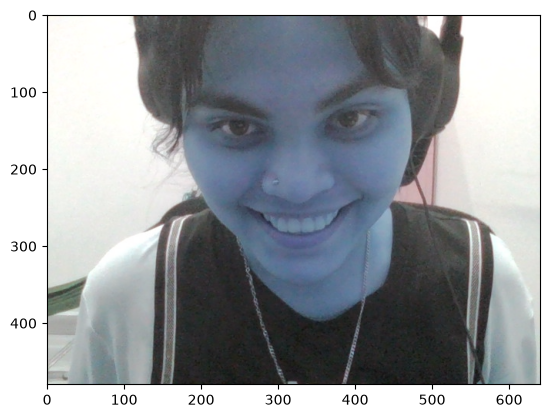

In [74]:
plt.imshow(frame)

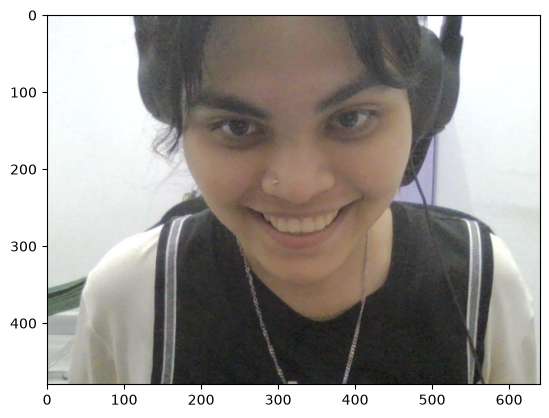

In [75]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

In [78]:
landmarks_draw(frame, results)

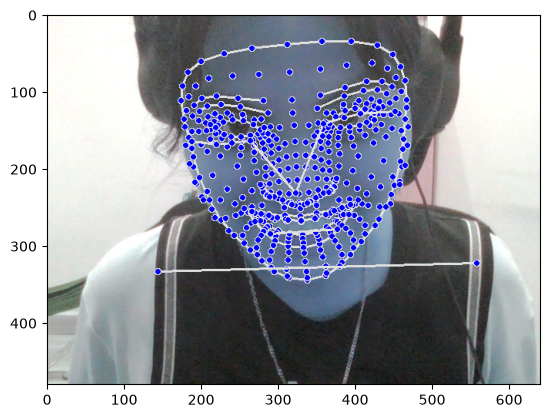

In [79]:
plt.imshow(frame)

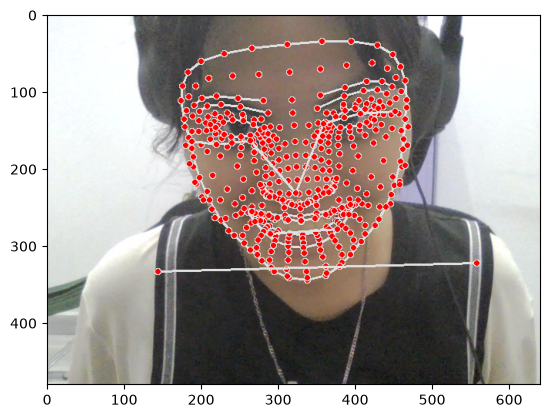

In [80]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))